In [7]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
from pathlib import Path
from mpltern.datasets import get_triangular_grid
from statsmodels.stats.multitest import fdrcorrection
from tqdm import tqdm
import os
import pybedtools
BOXPROPS, period_palette, sex_palette, celltype_palette, period_order = apply_plot_settings()

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sc
from plot_settings import apply_plot_settings, read_meta

In [15]:
qcfile = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/metadata_DNA_QC.tsv.gz',index_col = [0],compression='gzip', header=0, sep='\t')

## DMRs Summary

In [9]:
DMR_period_order = ['Infancy',
 'Early_Childhood',
 'Late_Childhood',
 'Adolescence',
 'Adulthood',
 'Late_Adulthood']

/tmp/ipykernel_1805625/2806826141.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['comp1_tmp']=tmp['comp'].str.split('-').str[0]
/tmp/ipykernel_1805625/2806826141.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['comp2_tmp']=tmp['comp'].str.split('-').str[1]
/tmp/ipykernel_1805625/2806826141.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

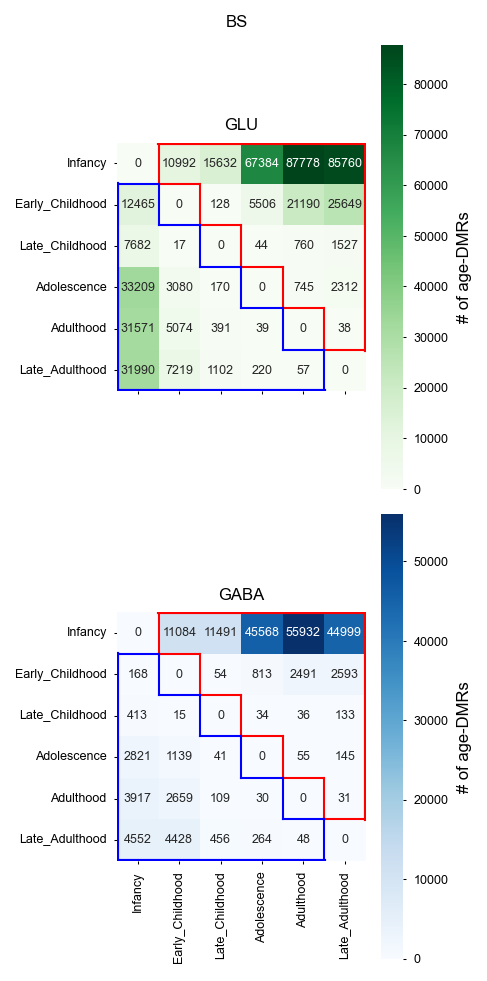

In [10]:
assay = 'BS'
fig,axs=plt.subplots(2,1,figsize=(3.2,7),sharex=True,dpi=150)
df=pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/ageDMR.{assay}_ExSCZ_NoNorm.tsv.gz',sep='\t')
df=df[df['areaStat'].abs()>15]
for j, celltype in enumerate(['GLU','GABA']):
    ax=axs[j]
    tmp=df[df['celltype']==celltype]
    tmp['comp1_tmp']=tmp['comp'].str.split('-').str[0]
    tmp['comp2_tmp']=tmp['comp'].str.split('-').str[1]
    tmp['comp1']=tmp['comp1_tmp']
    tmp.loc[tmp['areaStat'] > 0, 'comp1'] = tmp['comp2_tmp']
    tmp['comp2']=tmp['comp2_tmp']
    tmp.loc[tmp['areaStat'] > 0, 'comp2'] = tmp['comp1_tmp']
    tmp=tmp.drop(columns=['comp1_tmp','comp2_tmp'])
    tmp=tmp.groupby(['comp1','comp2']).size().to_frame('n').reset_index().pivot(index='comp1',columns='comp2',values='n')\
         .loc[DMR_period_order,DMR_period_order].fillna(0).astype(int)

    if celltype == 'GLU':
        sns.heatmap(tmp,cmap='Greens', annot=True, fmt='g',annot_kws={"fontsize":6}, cbar_kws={'label':'# of age-DMRs'},square=True, ax=ax)
    else:
        sns.heatmap(tmp,cmap='Blues', annot=True, fmt='g',annot_kws={"fontsize":6}, cbar_kws={'label':'# of age-DMRs'},square=True, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')

    for i in range(tmp.shape[0]-1):
        ax.plot([i + 1 , i + 2], [i + 1, i + 1], color='r', linewidth=1)  
        ax.plot([i + 1, i + 1 ], [i + 1, i], color='r', linewidth=1)  
    ax.plot([1 , 6], [0 , 0 ], color='r', linewidth=2)  
    ax.plot([6 , 6], [0 , 5 ], color='r', linewidth=2)  
    for i in range(tmp.shape[0]-1):
        ax.plot([i + 1, i ],[i + 1 , i + 1], color='b', linewidth=1)  
        ax.plot([i + 1, i + 1],[i + 1, i +2], color='b', linewidth=1)
    ax.plot([0 , 5], [6 , 6 ], color='b', linewidth=2)  
    ax.plot([0 , 0], [1 , 6 ], color='b', linewidth=2) 
    ax.set_title(celltype)
plt.suptitle(assay)
plt.tight_layout()
# plt.savefig(f'/cndd2/jchien/project/Dracheva_Development/Figure/Num_ageDMR_{assay}_areastat15.pdf',dpi=150)

417.0
0.014227839666666667
489.0
0.03404617333333333


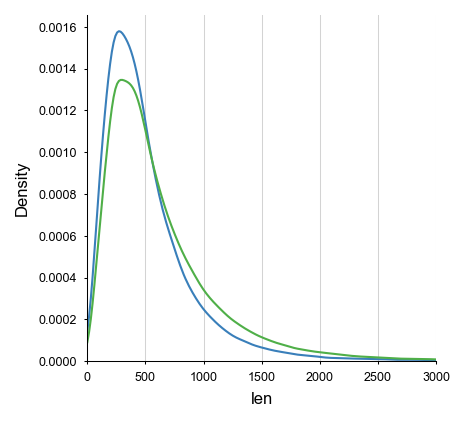

In [11]:
plt.figure(figsize=(3,3),dpi=150)
df=pd.read_csv('/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/ageDMR.GABA_BS_ExSCZ_NoNorm_merge_autosome.bed.gz',sep='\t',names=['chr','start','end'])
df['len'] = df['end'] - df['start']
print(df['len'].median())
print(df['len'].sum()/3e9)
sns.kdeplot(data = df, x='len', color = celltype_palette['GABA'],linewidth=1,clip=[0,3000])
df=pd.read_csv('/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/ageDMR.GLU_BS_ExSCZ_NoNorm_merge_autosome.bed.gz',sep='\t',names=['chr','start','end'])
df['len'] = df['end'] - df['start']
print(df['len'].median())
print(df['len'].sum()/3e9)
sns.kdeplot(data = df, x='len', color = celltype_palette['GLU'],linewidth=1,clip=[0,3000])
plt.xlim([0,3000])
plt.grid(axis='x')
# plt.savefig(f'/cndd2/jchien/project/Dracheva_Development/Figure/ageDMR_lendist_areastat15.pdf',dpi=150)

## Fit DMR with 3-State Model

In [7]:
# import scipy as sc
# from scipy.integrate import odeint
# from sklearn.metrics import r2_score

# def model(y, t, tauC, tauM, tauH):
#     C, M = y
#     dCdt = -C/tauC + (1-C-M)/tauH
#     dMdt = C/tauC - M/tauM
#     return [dCdt, dMdt]

# def fit_func(t, tauC, tauM, tauH, C0, M0):
#     y0 = [C0, M0]
#     y_fit = odeint(model, y0, t, args=(tauC, tauM, tauH))
#     return y_fit.ravel()

# def fit_model(ioi):
#     df = (1-bs[[ioi]]).join(ox[[ioi]], rsuffix='_o').join(hmc[[ioi]], rsuffix='_h')
#     df.columns=['C','mC','hmC']
#     df['age']=df.index.map(agedict)
#     df=df.dropna().sort_values('age')
#     if len(df) > 5:
#         params_guess = [1,1,1,df.iloc[0]['C'],df.iloc[0]['mC']]
        
#         try:
#             params_fit, pcov = sc.optimize.curve_fit(fit_func,  df['age'].values,  df[['C','mC']].values.ravel(),\
#                                                      p0 = params_guess, bounds = ([0, 0, 0, 0, 0], [77, 77, 77, 1, 1]), method='trf', maxfev = 8000)
#             pstd = np.sqrt(np.diag(pcov))
#             bspred=1-odeint(model, params_fit[3:6], df['age'], args=tuple(params_fit[0:3]))[:,0]
#             oxpred=odeint(model, params_fit[3:6], df['age'], args=tuple(params_fit[0:3]))[:,1]
#             hmcpred=1-odeint(model, params_fit[3:6], df['age'], args=tuple(params_fit[0:3]))[:,0]-odeint(model, params_fit[3:6], df['age'], args=tuple(params_fit[0:3]))[:,1]
#             R2=[r2_score((1-df['C']),bspred), r2_score(df['mC'],oxpred), r2_score(df['hmC'],hmcpred)]
        
#         except RuntimeError:
#             print(f"{ioi}: curve_fit failed")
#             params_fit=[np.nan]*5
#             pstd=[np.nan]*5
#             R2=[np.nan]*3
        
#     else:
#         params_fit=[np.nan]*5
#         pstd=[np.nan]*5
#         R2=[np.nan]*3
#     return ioi, params_fit, pstd, R2

## DMR Cluster (scatter + line plot)

In [12]:
PECmeta=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS.csv',index_col=0)
agedict=dict(zip(PECmeta.index, PECmeta['age']))
sexdict=dict(zip(PECmeta.index, PECmeta['sex']))
perioddict=dict(zip(PECmeta.index, PECmeta['period']))

#### GLU

In [16]:
celltype='GLU'

bs=[]
ox=[]
donors=qcfile[(qcfile['celltype']==celltype)&(qcfile['DNA_passQC']=='True')]['donor'].unique()
for donor in tqdm(donors):
    file=f'/cndd2/jchien/project/Dracheva_Development/regionMethylation/DMR/p0.01/BSonly_areastat15/{donor}_{celltype}_BS.DMR-{celltype}-BS-merged-areastate15_CGN-Both.sparse.bed.gz'
    tmp=pd.read_csv(file,sep='\t',header=None, names=['chr','start','end','mc','c'], index_col=['chr','start','end'])
    tmp[donor]=tmp['mc']/tmp['c']
    bs.append(tmp[donor])
    del tmp
    tmp=pd.read_csv(file.replace('_BS','_OXBS'),sep='\t',header=None, names=['chr','start','end','mc','c'], index_col=['chr','start','end'])
    tmp[donor]=tmp['mc']/tmp['c']
    ox.append(tmp[donor])
bs=pd.DataFrame(bs)
ox=pd.DataFrame(ox)
hmc=bs.sub(ox)

100%|██████████| 66/66 [00:17<00:00,  3.74it/s]


In [17]:
dmr=pd.read_csv(f'./data/ageDMR.GLU_BS_ExSCZ_NoNorm_merge_autosome.bed.gz',sep='\t',names=['chr','start','end'],index_col=[0])
dmr['len']=dmr['end']-dmr['start']
print(dmr['len'].sum()/3e9)
print(dmr['len'].mean())

0.03404617333333333
644.6755115694864


In [18]:
lenthres=0
R2thres=-np.inf
agethres = 5
ref = pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/bsmax050_fc030/ageDMR.{celltype}_BS_ExSCZ_NoNorm_merge_autosome_bsmax050_fc030.bed.gz',sep='\t',names=['chr','start','end'],index_col=[0,1,2])
summary=pd.read_csv(f'/cndd2/jchien/project/Dracheva_Development/odefit/p0.01/BSonly_areastat15/DMR_{celltype}_initialguess111_maxt77.tsv.gz',sep='\t',header=[0,1],index_col=[0,1,2])
summary.index.names = ['chr','start','end']
print(summary.shape)
summary = summary.loc[ref.index]
print(summary.shape)
summary_sub=summary[(summary[('R2','C')]>R2thres)&(summary[('R2','mC')]>R2thres)&(summary[('R2','hmC')]>R2thres)].xs('tau',axis=1).join(summary.xs('y0',axis=1)[['C','mC']],rsuffix='_y0').reset_index()
print(summary_sub.shape)

summary_sub['hmC_y0']=1-summary_sub['C_y0']-summary_sub['mC_y0']
summary_sub.loc[summary_sub['hmC_y0'] < 0, 'hmC_y0'] = 0
summary_sub['totaltau']=summary_sub['C']+summary_sub['mC']+summary_sub['hmC']

# steady state
summary_sub['C_yinf']=(summary_sub['C'])/(summary_sub['totaltau'])
summary_sub['mC_yinf']=(summary_sub['mC'])/(summary_sub['totaltau'])
summary_sub['hmC_yinf']=(summary_sub['hmC'])/(summary_sub['totaltau'])

# up/down
summary_sub['C_yinf/C_y0']=(summary_sub['C_yinf'])/(summary_sub['C_y0'])
summary_sub['mC_yinf/mC_y0']=(summary_sub['mC_yinf'])/(summary_sub['mC_y0'])
summary_sub['hmC_yinf/hmC_y0']=(summary_sub['hmC_yinf'])/(summary_sub['hmC_y0'])



# summary_sub = summary_sub[['C_yinf/C_y0','mC_yinf/mC_y0','hmC_yinf/hmC_y0']]

summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']<1)&(summary_sub['hmC_yinf/hmC_y0']>1)&(summary_sub['mC']<=agethres) ,'cluster'] = '+-+_fast'
summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']<1)&(summary_sub['hmC_yinf/hmC_y0']>1)&(summary_sub['mC']>agethres) ,'cluster'] = '+-+_slow'
summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']>1)&(summary_sub['mC']<=agethres) ,'cluster'] = '+++_fast'
summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']>1)&(summary_sub['mC']>agethres) ,'cluster'] = '+++_slow'
summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']<1)&(summary_sub['hmC_yinf/hmC_y0']<1) ,'cluster'] = '3'
summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']<1) ,'cluster'] = '4'
summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']<1)&(summary_sub['mC']<=agethres) ,'cluster'] = '++-_fast'
summary_sub.loc[(summary_sub['C_yinf/C_y0']<1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']<1)&(summary_sub['mC']>agethres) ,'cluster'] = '++-_slow'

summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']<1)&(summary_sub['hmC_yinf/hmC_y0']>1)&(summary_sub['mC']<=agethres) ,'cluster'] = '--+_fast'
summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']<1)&(summary_sub['hmC_yinf/hmC_y0']>1)&(summary_sub['mC']>agethres) ,'cluster'] = '--+_slow'
summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']>1) ,'cluster'] = '6'
summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']<1)&(summary_sub['hmC_yinf/hmC_y0']<1)&(summary_sub['mC']<=agethres) ,'cluster'] = '---_fast'
summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']<1)&(summary_sub['hmC_yinf/hmC_y0']<1)&(summary_sub['mC']>agethres) ,'cluster'] = '---_slow'
summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']<1) ,'cluster'] = '8'
summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']<1)&(summary_sub['mC']<=agethres) ,'cluster'] = '-+-_fast'
summary_sub.loc[(summary_sub['C_yinf/C_y0']>1)&(summary_sub['mC_yinf/mC_y0']>1)&(summary_sub['hmC_yinf/hmC_y0']<1)&(summary_sub['mC']>agethres) ,'cluster'] = '-+-_slow'

summary_sub = summary_sub.set_index(['chr','start','end'])
print(summary_sub['cluster'].value_counts())
# summary_sub[summary_sub['cluster']!=False][['cluster']].to_csv(f'/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/bsmax050_fc030/cluster_supervise/{celltype}_taumc-{agethres}.bed.gz',sep='\t', header=None)

(158434, 12)
(146966, 12)
(146966, 8)
+++_fast    43225
+++_slow    40321
--+_fast    24965
+-+_fast    10775
---_fast    10211
+-+_slow     9141
--+_slow     5638
---_slow     2400
++-_slow      219
++-_fast       40
-+-_fast       20
-+-_slow       11
Name: cluster, dtype: int64


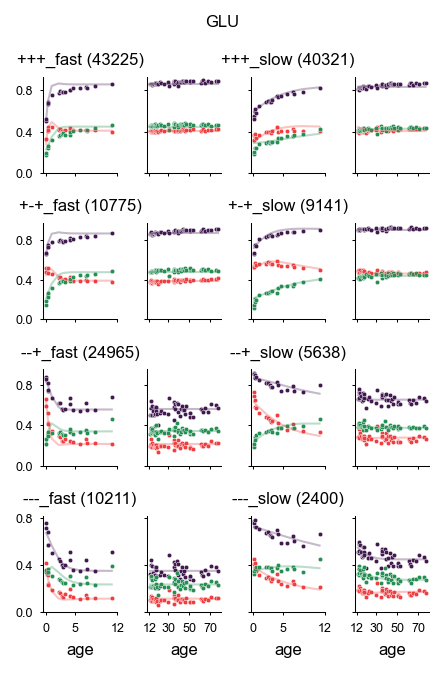

In [ ]:
from scipy.integrate import odeint
def model(y, t, tauC, tauM, tauH):
    C, M = y
    dCdt = -C/tauC + (1-C-M)/tauH
    dMdt = C/tauC - M/tauM
    return [dCdt, dMdt]

def fit_func(t, tauC, tauM, tauH, C0, M0):
    y0 = [C0, M0]
    y_fit = odeint(model, y0, t, args=(tauC, tauM, tauH))
    return y_fit.ravel()

cat_order = ['+++_fast','+++_slow','+-+_fast','+-+_slow','--+_fast','--+_slow','---_fast','---_slow']
fig,axs=plt.subplots(4, 4, figsize=(3, 4.5), dpi=150, sharex='col', sharey='row')
for i, cat in enumerate(cat_order):
    n = len(summary_sub[summary_sub['cluster']==cat])
    
    tmp_bs=bs.T.loc[summary_sub[summary_sub['cluster']==cat].index.values].median().to_frame('tmC')
    tmp_ox=ox.T.loc[summary_sub[summary_sub['cluster']==cat].index.values].median().to_frame('mC')
    tmp_hmc = tmp_bs.rename(columns={'tmC':'hmC'})-tmp_ox.rename(columns={'mC':'hmC'})
    tmp_hmc[tmp_hmc<0]=0
    # tmp_hmc=hmc.T.loc[summary_sub[summary_sub['cluster']==cat].index.values].mean().to_frame('hmC')
    df = tmp_bs.join(tmp_ox).join(tmp_hmc)
    df['age'] = df.index.map(agedict)
    df = df.dropna().sort_values('age')
    
    df['C'] = 1-df['tmC']
    params_guess = [1,1,1,df.iloc[0]['C'],df.iloc[0]['mC']]
    params_fit, pcov = sc.optimize.curve_fit(fit_func,  df['age'].values,  df[['C','mC']].values.ravel(),\
                                             p0 = params_guess, bounds = ([0, 0, 0, 0, 0], [77, 77, 77, 1, 1]), method='trf', maxfev = 8000)
    all_pred = odeint(model, params_fit[3:], df['age'], args=tuple(params_fit[:3]))
    df_pred = pd.DataFrame({'age':df['age'],'C':all_pred[:, 0],'mC':all_pred[:, 1],'hmC':1 - all_pred.sum(axis=1)})
    df_pred['tmC'] = 1 - df_pred['C']
    

    ax=axs[(i//2), 2*(i%2)]
    sns.scatterplot(data=df[df['age']<=12], x='age', y='tmC',s=4.5,linewidth=0.2, color=assay_palette['C'],label='C',ax=ax)
    sns.scatterplot(data=df[df['age']<=12], x='age', y='mC',s=4.5,linewidth=0.2, color=assay_palette['mC'],label='mC',ax=ax)
    sns.scatterplot(data=df[df['age']<=12], x='age', y='hmC',s=4.5,linewidth=0.2, color=assay_palette['hmC'],label='hmC',ax=ax)
    sns.lineplot(data=df_pred[df_pred['age']<=12], x='age', y='tmC', linewidth=1, linestyle = '-', color=assay_palette['C'],ax=ax,alpha=0.3)
    sns.lineplot(data=df_pred[df_pred['age']<=12], x='age', y='mC', linewidth=1, linestyle = '-', color=assay_palette['mC'],ax=ax,alpha=0.3)
    sns.lineplot(data=df_pred[df_pred['age']<=12], x='age', y='hmC', linewidth=1, linestyle = '-', color=assay_palette['hmC'],ax=ax,alpha=0.3)
    ax.set_xticks([0,5,12])
    ax.set_yticks([0,0.4,0.8])
    # ax.set_title(f'tC: {params_fit[0]:.1f}, tM: {params_fit[1]:.1f}, tH: {params_fit[2]:.1f}')
    ax.legend().remove()
    ax.set_ylabel('')
    ax.set_title(f'{cat} ({n})')
    
    ax=axs[(i//2), 2*(i%2)+1]
    sns.scatterplot(data=df[df['age']>12], x='age', y='tmC',s=4.5,linewidth=0.2, color=assay_palette['C'],label='C',ax=ax)
    sns.scatterplot(data=df[df['age']>12], x='age', y='mC',s=4.5,linewidth=0.2, color=assay_palette['mC'],label='mC',ax=ax)
    sns.scatterplot(data=df[df['age']>12], x='age', y='hmC',s=4.5,linewidth=0.2, color=assay_palette['hmC'],label='hmC',ax=ax)
    sns.lineplot(data=df_pred[df_pred['age']>12], x='age', y='tmC', linewidth=1, linestyle = '-', color=assay_palette['C'],ax=ax,alpha=0.3)
    sns.lineplot(data=df_pred[df_pred['age']>12], x='age', y='mC', linewidth=1, linestyle = '-', color=assay_palette['mC'],ax=ax,alpha=0.3)
    sns.lineplot(data=df_pred[df_pred['age']>12], x='age', y='hmC', linewidth=1, linestyle = '-', color=assay_palette['hmC'],ax=ax,alpha=0.3)
    # ax.set_title(f'tC: {params_fit[0]:.1f}, tM: {params_fit[1]:.1f}, tH: {params_fit[2]:.1f}')
    ax.set_xticks([12,30,50,70])
    ax.legend().remove()
    ax.set_ylabel('')
    ax.set_yticks([0,0.4,0.8])
plt.suptitle(celltype)
plt.tight_layout()
# plt.savefig(f'/cndd2/jchien/project/Dracheva_Development/Figure/ageDMR_BSonly_supervise_cluster_areastat15_bsmax050_fc030_{celltype}_lineplot.pdf')

## Heatmap

In [20]:
def DMR_heatmap(df_kmeans, zscore=False, n_clusters=4, cluster_order=range(4)):
    fig,axs = plt.subplots(1,3, figsize=(4.5,4), sharex=True, sharey=True, dpi=150)
    for i in range(3):
        ax=axs[i]

        if zscore:
            cmap='RdBu_r'
            if i==0:
                tmp=bs_norm.T.loc[df_kmeans.index]
                title='Total mCG'
            elif i==1:
                tmp=ox_norm.T.loc[df_kmeans.index]
                title='mCG'
            else:
                tmp=hmc_norm.T.loc[df_kmeans.index].fillna(0)
                title='hmCG'
            tmp.columns = tmp.columns.map(agedict)
            tmp = tmp.sort_index(axis=1)
            sns.heatmap(tmp,
                        xticklabels=True,
                        yticklabels=False,
                        rasterized=True,
                        cmap=cmap,
                        center=0,
                        vmin=-3,
                        vmax=3,
                        cbar_kws={'shrink': 0.5,'panchor':(1,0)},
                        ax=ax
                        )
        else:
            cmap='rocket'
            if i==0:
                tmp=bs.T.loc[df_kmeans.index].fillna(0)
                title='Total mCG'
            elif i==1:
                tmp=ox.T.loc[df_kmeans.index].fillna(0)
                title='mCG'
            else:
                tmp=hmc.T.loc[df_kmeans.index].fillna(0)
                title='hmCG'
                
            # vmin=round(np.quantile(tmp, 0.05),1)
            # vmax=round(np.quantile(tmp, 1),1)
            # vmin=round(np.quantile(tmp, 0.01),1)
            vmin=0
            vmax=round(np.quantile(tmp, 0.99),1)
            tmp.columns = tmp.columns.map(agedict)
            tmp = tmp.sort_index(axis=1)
            # print(title,vmin,vmax)
            sns.heatmap(tmp,
                        xticklabels=True,
                        yticklabels=False,
                        rasterized=True,
                        cmap=cmap,
                        vmin=vmin,
                        vmax=vmax,
                        cbar_kws={'shrink': 0.5,'panchor':(1,0),'ticks':[vmin, (vmin+vmax)/2, vmax]},
                        ax=ax
                        )
        for n in range(n_clusters):
            ax.axhline(y=np.cumsum(df_kmeans['cluster'].value_counts()[cluster_order])[n],c='white',linewidth=0.5)
        ax.set_title(title)
        ax.set_ylabel(f'{len(df_kmeans)} union age-DMRs')
        if celltype == 'GLU':
            ax.set_xticks([5.5, 14.5, 18.5, 33.5, 55.5, 65.5])
            ax.set_xticklabels(['1', '5', '11', '20', '51','77'], rotation=0) 
        else:
            ax.set_xticks([5.5, 14.5, 19.5, 34.5, 55.5, 62.5])
            ax.set_xticklabels(['1',  '5', '11', '20', '51', '77'], rotation=0) 
    plt.suptitle(celltype)
    plt.tight_layout()

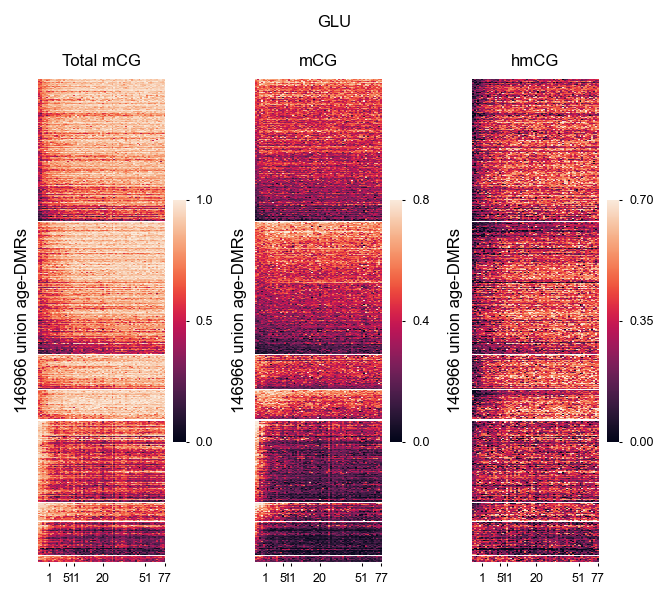

In [21]:
# zscore
hmc_norm = hmc.copy()
hmc_norm = ((hmc_norm-hmc_norm.mean())/hmc_norm.std())

bs_norm = bs.copy()
bs_norm = ((bs_norm-bs_norm.mean())/bs_norm.std())

ox_norm = ox.copy()
ox_norm = ((ox_norm-ox_norm.mean())/ox_norm.std())

summary_sub['C_yinf-C_y0']=((summary_sub['C_yinf'])-(summary_sub['C_y0']))/((summary_sub['C_y0']))
summary_sub['mC_yinf-mC_y0']=((summary_sub['mC_yinf'])-(summary_sub['mC_y0']))/((summary_sub['mC_y0']))
summary_sub['hmC_yinf-hmC_y0']=((summary_sub['hmC_yinf'])-(summary_sub['hmC_y0']))/((summary_sub['hmC_y0']))
df_kmeans = summary_sub[(summary_sub['cluster']!=False)][['cluster','mC_y0','mC_yinf/mC_y0','hmC_y0','hmC_yinf/hmC_y0']]
df_kmeans['cluster'] = pd.Categorical(df_kmeans['cluster'],
                                      categories=['+++_fast','+++_slow','+-+_fast','+-+_slow','++-_fast','++-_slow','--+_fast','--+_slow','---_fast','---_slow','-+-_fast','-+-_slow'],
                                      ordered=True)
# df_kmeans = df_kmeans.sort_values(['mC_yinf-mC_y0','mC_y0','hmC_yinf-hmC_y0','hmC_y0'],ascending=[False,False,False,False])
df_kmeans = df_kmeans.sort_values(['cluster','mC_y0','mC_yinf/mC_y0','hmC_y0','hmC_yinf/hmC_y0'],ascending=[True,False,False,False,False])
# df_kmeans = df_kmeans.sort_values(['cluster','hmC_y0','hmC_yinf/hmC_y0','mC_y0','mC_yinf/mC_y0'],ascending=[True,False,False,False,False])
# idx_order = np.argsort(df_kmeans.cluster)
# df_kmeans = df_kmeans.iloc[idx_order]
idx_order = df_kmeans.index
df_kmeans = df_kmeans.loc[idx_order]
DMR_heatmap(df_kmeans, zscore=False, n_clusters=12, cluster_order=['+++_fast','+++_slow','+-+_fast','+-+_slow','++-_fast','++-_slow','--+_fast','--+_slow','---_fast','---_slow','-+-_fast','-+-_slow'])
# plt.savefig(f'/cndd2/jchien/project/Dracheva_Development/Figure/ageDMR_BSonly_supervise_cluster_areastat15_bsmax050_fc030_{celltype}_heatmap.pdf',dpi=600)

## Tenary Plot

In [22]:
period_palette={'Infancy': '#F7C98A',
'Early_Childhood': '#F4A154',
'Late_Childhood': '#EF7A3B',
'Adolescence': '#D2614D',
'Early_Adulthood': '#9D4255',
'Adulthood': '#9D4255',
'Late_Adulthood': '#774147'
        }

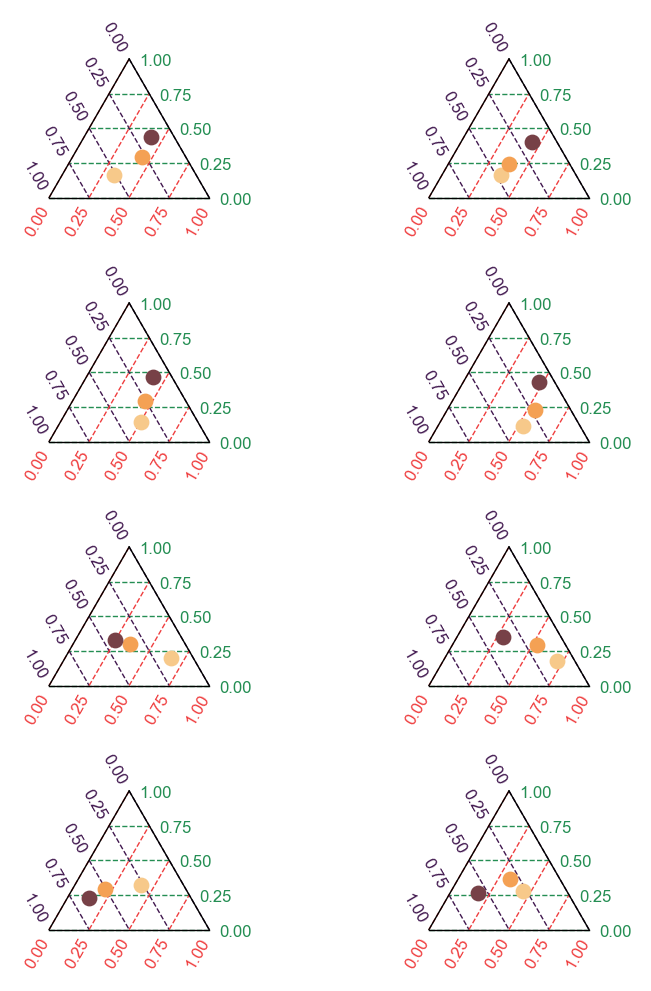

In [25]:
from mpltern.datasets import get_triangular_grid
assay_palette = {
    'C': '#41184F',
    'mC': '#EF3E3F',
    'hmC': '#248E53',
}
cat_order = ['+++_fast','+++_slow','+-+_fast','+-+_slow','--+_fast','--+_slow','---_fast','---_slow']
def process_cluster_data(cluster_index):
    tmp_bs = bs.T.loc[summary_sub[summary_sub['cluster']==cluster_index].index.values].mean().to_frame('C')
    tmp_ox = ox.T.loc[summary_sub[summary_sub['cluster']==cluster_index].index.values].mean().to_frame('mC')
    df = (1 - tmp_bs).join(tmp_ox, rsuffix='_o')
    df['hmC'] = 1 - df['C'] - df['mC']
    df['age'] = df.index.map(agedict)
    df['period']=df.index.map(perioddict)
    df=df.dropna().sort_values('age')
    # df = df.groupby('period').mean()
    return df

def customize_ternary_axes(ax):
    # Enable grid globally
    ax.grid(True)
    ticks = np.linspace(0,1,5)
    ax.taxis.set_ticks(ticks)
    ax.laxis.set_ticks(ticks)
    ax.raxis.set_ticks(ticks)



    # Remove ticks and labels
    # for axis in [ax.taxis, ax.laxis, ax.raxis]:
    #     axis.set_ticks([])
    #     axis.set_ticklabels([])

    ax.tick_params(tick1On=False, tick2On=False)
    ax.taxis.set_tick_params(tick1On=False, tick2On=False, colors=assay_palette['hmC'], grid_color=assay_palette['hmC'], grid_linestyle='--', size=0.2)
    ax.laxis.set_tick_params(tick1On=False, tick2On=False, colors=assay_palette['C'], grid_color=assay_palette['C'], grid_linestyle='--', size=0.2)
    ax.raxis.set_tick_params(tick1On=False, tick2On=False, colors=assay_palette['mC'], grid_color=assay_palette['mC'], grid_linestyle='--', size=0.2)
    # ax.taxis.label.set_color(assay_palette['hmC'])
    # ax.laxis.label.set_color(assay_palette['C'])
    # ax.raxis.label.set_color(assay_palette['mC'])

# def scatter_important_points(ax, df):
#     for i, period in enumerate(period_order):
#         ax.scatter(df.loc[period]['hmC'], df.loc[period]['C'], df.loc[period]['mC'], 
#                    color=period_palette[period], zorder=-1, s=50)
def scatter_important_points(ax, df):
    period_colors = ['Infancy', 'Early_Childhood', 'Late_Adulthood']
    period_indices = [0, 5, -1]  # Indices of the points to highlight
    for i, period in enumerate(period_colors):
        idx = period_indices[i]
        ax.scatter(df.iloc[idx]['hmC'], df.iloc[idx]['C'], df.iloc[idx]['mC'], 
                       color=period_palette[period], zorder=1, s=22, alpha = 1)

rows, cols = 4, 2
fig, axes = plt.subplots(
    nrows=rows, ncols=cols,
    subplot_kw={"projection": "ternary"},
    figsize=(4, 5), dpi=200,  # adjust size as you like
)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

axes_flat = axes.ravel()
for ax in axes_flat[len(cat_order):]:
    ax.set_visible(False)  # hide unused panels if any

for ax, cat in zip(axes_flat, cat_order):
    df = process_cluster_data(cat)
    customize_ternary_axes(ax)
    scatter_important_points(ax, df)

plt.tight_layout()
# plt.savefig(f"/cndd/hex002/PsychEncode/Figures/ageDMR_BSonly_supervise_cluster_{celltype}_ternary.pdf")

## DMR Enrichment

### Shuffle test func

In [ ]:
# def suffleDMRs(dmrfile, features, celltype):

#     shufflesummary = pd.DataFrame(columns=['ratio', 'z', 'fold_change', 'p'], index=features) 
#     dmr = pybedtools.BedTool(dmrfile)
#     total_dmrs = len(dmr)  # Total number of DMRs
    
#     for n, feature in enumerate(features):
        
#         featurefile = '{dir}/{feature_bed_file}'
       
#         region = pybedtools.BedTool(featurefile).merge()
        
#         overlapping_dmrs = dmr.intersect(region, u=True)  # Unique DMRs that overlap
#         num_overlapping = len(overlapping_dmrs)
#         observed_ratio = num_overlapping / total_dmrs if total_dmrs > 0 else 0
        
#         dmr_merged = dmr.merge()
#         dmr_and_region = dmr_merged.intersect(region)
#         if len(dmr_and_region) > 0:
#             dmr_and_region_df = pd.read_table(dmr_and_region.fn, header=None)
#             dmr_and_region_df = dmr_and_region_df.rename(columns={0: 'chr', 1: 'start', 2: 'end'})
#             dmr_and_region_df['length'] = dmr_and_region_df['end'] - dmr_and_region_df['start']
#             n0 = dmr_and_region_df['length'].sum()
#         else:
#             n0 = 0
        
#         # Shuffle
#         ns = []
#         for i in range(100):
#             dmr_s = dmr_merged.shuffle(genome='hg38', chrom=True, noOverlapping=True, excl='hg38-blacklist.v2.bed.gz', seed=i)
#             dmr_and_region = dmr_s.intersect(region)
#             if len(dmr_and_region) > 0:
#                 dmr_and_region = pd.read_table(dmr_and_region.fn, header=None)
#                 dmr_and_region = dmr_and_region.rename(columns={0: 'chr', 1: 'start', 2: 'end'})
#                 dmr_and_region['length'] = dmr_and_region['end'] - dmr_and_region['start']
#                 ns.append(dmr_and_region['length'].sum())
#             else:
#                 ns.append(0)

#         # Fit normal distribution
#         mu, std = stats.norm.fit(ns)
#         if (std > 0) & (n0 >= 0):  # Check for valid z-score
#             z = (n0 - mu) / std
#             if z > 0:
#                 p_values = (n0 < np.array(ns)).sum() / len(ns)
#             else:
#                 p_values = (n0 > np.array(ns)).sum() / len(ns)
#         else:
#             z = np.nan
#             p_values = np.nan
        
#         # Calculate fold change
#         if mu > 0: 
#             fold_change = n0 / mu
#         else:
#             fold_change = np.nan

#         shufflesummary.loc[feature] = [observed_ratio, z, fold_change, p_values]

#         ax = axs[n // 5, n % 5]
#         ax.hist(ns, alpha=0.5, bins=20)
#         ax.axvline(x=n0, c='r')
#         ax.set_title(f'{feature}\nRatio={observed_ratio:.2f}, z={z:.1f}, FC={fold_change:.1f}, p={p_values:.2f}', fontsize=6)
#         ax.tick_params(axis='both', which='major', labelsize=6)

#     plt.suptitle(dmrfile, fontsize=6)
#     plt.tight_layout()
#     outfile = dmrfile.split('/')[-1].split('.')[0]
#     plt.close()
#     pybedtools.cleanup()
    
#     return shufflesummary
# features = [
#     'intragenic','intragenic_exp','intragenic_nonexp','intergenic',
#     'pol_up','pol_down','pol_nondiff',
#     'enhancer_up','enhancer_down','enhancer_nondiff',
#     'promoter_up','promoter_down','promoter_nondiff',
#     'het_up','het_down','het_nondiff'
# ]

# outdir = Path('/cndd/hex002/PsychEncode/methylation/DMR/compartment_enrichment')
# outdir.mkdir(parents=True, exist_ok=True)

# clusters = ['+-+_fast','+++_fast','--+_fast','---_fast',
#             '+-+_slow','+++_slow','--+_slow','---_slow']

# futures = {}
# max_workers = 10

# with ProcessPoolExecutor(max_workers=max_workers) as exe:
#     for celltype in ['GLU', 'GABA']:
#         for cl in clusters:
#             dmrfile = f'/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/bsmax050_fc030/cluster_supervise/split_bed/{celltype}_{cl}.bed'
#             fut = exe.submit(suffleDMRs, dmrfile, features, celltype)
#             futures[fut] = (celltype, cl, dmrfile)

#     for fut in as_completed(futures):
#         celltype, cl, dmrfile = futures[fut]
#         try:
#             summary = fut.result() 
            
#             basename = Path(dmrfile).stem  
#             outpath = outdir / f'{basename}.csv.gz'
#             summary.to_csv(outpath)
#             print(f'[saved] {outpath}')
#         except Exception as e:
#             print(f'[error] {celltype} {cl}: {e}')

In [ ]:
# features = ['cgi','cgshore','intragenic','intergenic']
# for celltype in ['GLU','GABA']:
#     for i in [['+-+_fast', '+-+_slow'], ['+++_fast', '+++_slow']]:
#         for pol_type in ['open','close']:
#             dmr_files = [f'/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/bsmax050_fc030/cluster_supervise/split_bed/{celltype}_{i[0]}.bed',
#                         f'/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/bsmax050_fc030/cluster_supervise/split_bed/{celltype}_{i[1]}.bed']
#             # Load DMRs without merging to preserve individual regions
#             dmrs = pybedtools.BedTool(dmr_files[0]).cat(pybedtools.BedTool(dmr_files[1]), postmerge=False)
#             pol_file = f'/cndd/hex002/PsychEncode/ChIP/peaks/tmp/{celltype}_Pol_peaks_annotated_EDGER.{pol_type}.bed'   
#             pol = pybedtools.BedTool(pol_file)
#             overlap = dmrs.intersect(pol, u=True).sort()
#             summary = suffleDMRs(overlap, features, celltype, figname=f'{celltype}_{i[0]}_{i[1]}_pol_{pol_type}_enrichment')
#             summary.to_csv(f'/cndd/hex002/PsychEncode/methylation/DMR/compartment_enrichment/{celltype}_{i[0]}_{i[1]}_pol_{pol_type}.csv.gz')

/home/AD/hex002/miniconda3/envs/allcools_HX/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/AD/hex002/miniconda3/envs/allcools_HX/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


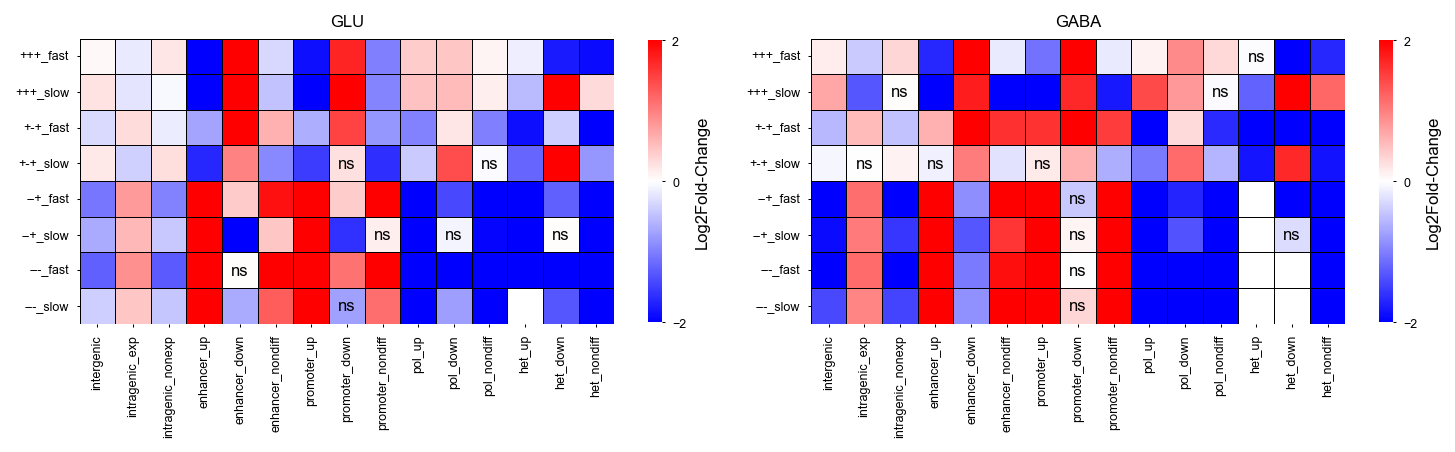

In [28]:
cat_order = ['+++_fast','+++_slow','+-+_fast','+-+_slow','--+_fast','--+_slow','---_fast','---_slow']
feature_order = ['intergenic','intragenic_exp',   'intragenic_nonexp',                
                 'enhancer_up','enhancer_down','enhancer_nondiff',
                'promoter_up','promoter_down','promoter_nondiff',
                'pol_up','pol_down','pol_nondiff',
                'het_up','het_down','het_nondiff',]

fig,axs=plt.subplots(1,2,figsize=(10,4),dpi=150)

for i, celltype in enumerate(['GLU', 'GABA']):
    enrich_list = []

    for cat in cat_order:
        tmp = pd.read_csv(
            f'/cndd/hex002/PsychEncode/methylation/DMR/compartment_enrichment/{celltype}_{cat}.csv.gz',
            sep=',',
            index_col=0
        )
        tmp['cat'] = cat
        enrich_list.append(tmp)

    enrich = pd.concat(enrich_list)

    # FDR correction
    _, enrich['FDR'] = fdrcorrection(enrich['p'])

    # Compute log2FC
    enrich['log2FC'] = np.log2(enrich['fold_change'])

    # Prepare heatmap values and FDR-based annotation
    enrich = enrich.reset_index()
    heatmap_data = enrich.pivot(index='cat', columns='index', values='log2FC').loc[cat_order, feature_order]
    fdr_matrix = enrich.pivot(index='cat', columns='index', values='FDR').loc[cat_order, feature_order]
    annot_matrix = fdr_matrix.applymap(lambda x: "ns" if x > 0.05 else "")

    # annot_matrix = enrich.applymap(lambda x: "*" if x == 0 else "")        
    sns.heatmap(
        heatmap_data,
        cmap='bwr',
        center=0,
        vmin=-2,
        vmax=2,
        ax=axs[i],
        linewidths=0.25,
        linecolor='black',
        cbar_kws={'shrink': 0.5, 'label': 'Log2Fold-Change', 'ticks': [-2, 0, 2]},
        square=True,
        annot=annot_matrix,
        fmt="",  # Important: don't format as a number
        annot_kws={"fontsize": 8, "color": "black"}  # Customize as needed
    )
    
    axs[i].set_title(celltype)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
plt.tight_layout()    
# plt.savefig(f'/cndd/hex002/PsychEncode/Figures/ageDMR_BSonly_CHIP_fc_1007.pdf',dpi=150)

## HOMER

In [ ]:
# findMotifsGenome.pl ${file} hg38 ./${folder} -size 200

/home/AD/hex002/miniconda3/envs/allcools_HX/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/AD/hex002/miniconda3/envs/allcools_HX/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/AD/hex002/miniconda3/envs/allcools_HX/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/AD/hex002/miniconda3/envs/allcools_HX/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/AD/hex002/miniconda3/envs/allcools_HX/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufun

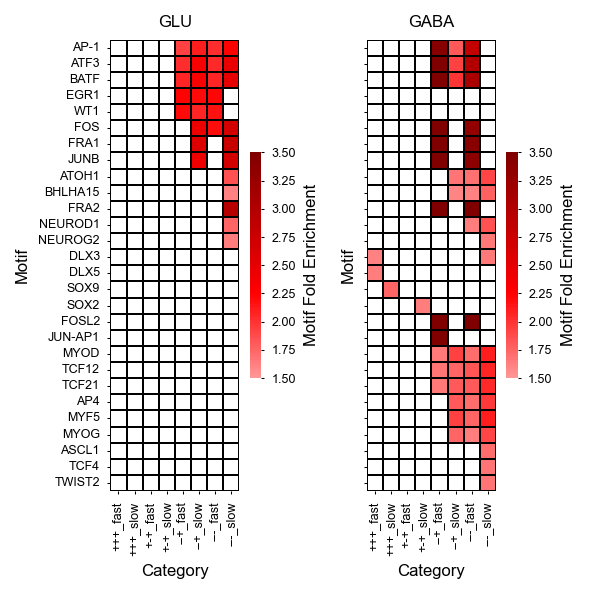

In [27]:
cat_order = ['+++_fast', '+++_slow', '+-+_fast', '+-+_slow', '--+_fast', '--+_slow', '---_fast', '---_slow']

all_motif_results = {}
for celltype in ['GLU', 'GABA']:
    all_results = []
    
    for cat in cat_order:
        file = f'/cndd2/jchien/project/Dracheva_Development/DMR/diffp/p0.01/areastat15/bsmax050_fc030/cluster_supervise/HOMER/{celltype}_{cat}/knownResults.txt'
        tmp = pd.read_csv(file, sep='\t')
        tmp = tmp.set_index('Motif Name')
        tmp['% of Target Sequences with Motif'] = tmp['% of Target Sequences with Motif'].str.replace('%', '').astype(float)
        tmp['% of Background Sequences with Motif'] = tmp['% of Background Sequences with Motif'].str.replace('%', '').astype(float)

        # Compute enrichment
        tmp['enrich'] = tmp['% of Target Sequences with Motif'] / tmp['% of Background Sequences with Motif']
        tmp['log2enrich'] = np.log2(tmp['enrich'])
        tmp.index = tmp.index.str.split('(').str[0].str.upper()  # Format motif names
        tmp['category'] = cat

        # Apply filtering criteria for significance
        # tmp['sig'] = (tmp['q-value (Benjamini)'] < 1e-3) & (tmp['% of Target Sequences with Motif'] > 10) & (tmp['enrich'] > 1.6) & ~(tmp.index.str.contains('UNKNOWN'))
        tmp['sig'] = (tmp['q-value (Benjamini)'] < 1e-5) & (tmp['% of Target Sequences with Motif'] > 10) & (tmp['enrich'] > 1.6) & ~(tmp.index.str.contains('UNKNOWN')) & ~(tmp.index.str.contains('\?'))

        
        filtered = tmp[tmp['sig']][['enrich', 'category']]
        all_results.append(filtered)

        all_motif_results[celltype] = pd.concat(all_results) if all_results else pd.DataFrame(columns=['enrich', 'category'])

combined_results = pd.concat(all_motif_results.values(), keys=all_motif_results.keys(), names=['CellType', 'Motif'])
heatmap_data = combined_results.reset_index().pivot_table(
    index='Motif', columns=['CellType', 'category'], values='enrich', aggfunc='mean'
)

for celltype in ['GLU', 'GABA']:
    for cat in cat_order:
        if (celltype, cat) not in heatmap_data.columns:
            heatmap_data[(celltype, cat)] = np.nan

motif_order = []
seen_motifs = set()
for cat in cat_order:
    motifs_in_cat = heatmap_data['GLU'][cat].dropna().index.tolist()
    for motif in motifs_in_cat:
        if motif not in seen_motifs:
            motif_order.append(motif)
            seen_motifs.add(motif)
for cat in cat_order:
    motifs_in_cat = heatmap_data['GABA'][cat].dropna().index.tolist()
    for motif in motifs_in_cat:
        if motif not in seen_motifs:
            motif_order.append(motif)
            seen_motifs.add(motif)

heatmap_data = heatmap_data.loc[motif_order]
heatmap_glu = heatmap_data['GLU']
heatmap_gaba = heatmap_data['GABA']

fig, axs = plt.subplots(1, 2, figsize=(4, 4), dpi=150, sharey=True)
for i, (celltype, heatmap_subset) in enumerate(zip(['GLU', 'GABA'], [heatmap_glu, heatmap_gaba])):
    ax = axs[i]

    sns.heatmap(
        heatmap_subset[cat_order],
        cmap='seismic',
        cbar_kws={'label': 'Motif Fold Enrichment', 'shrink': 0.5},
        center=1,
        vmin=1.5,
        vmax=3.5,
        linewidths=0.1, 
        linecolor='k',
        square=True,
        ax=ax
    )

    ax.set_title(f'{celltype}')
    ax.set_xlabel('Category')
    if i == 0:
        ax.set_ylabel('Motif')

plt.tight_layout()